In [2]:
# Core
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier
# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
# Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"saishanthvalasapalli","key":"37c81d6a5cccc942a9ee858744ebcedc"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!pip install kaggle

In [8]:
!kaggle datasets list -s credit

ref                                                        title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sakshigoyal7/credit-card-customers                         Credit Card customers                         387771  2020-11-19 07:38:44.677000         137450       2434  1.0              
mlg-ulb/creditcardfraud                                    Credit Card Fraud Detection                 69155672  2018-03-23 01:17:27.913000        1087481      12933  0.85294116       
rikdifos/credit-card-approval-prediction                   Credit Card Approval Prediction              5578875  2020-03-24 10:04:48.753000          97982        914  1.0              
parisrohan/credit-score-classification                     Credit score cla

In [13]:
!kaggle datasets download -d wordsforthewise/lending-club

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
 98% 1.24G/1.26G [00:09<00:00, 259MB/s]
100% 1.26G/1.26G [00:09<00:00, 145MB/s]


In [14]:
!unzip lending-club.zip

Archive:  lending-club.zip
  inflating: accepted_2007_to_2018Q4.csv.gz  
  inflating: accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv  
  inflating: rejected_2007_to_2018Q4.csv.gz  
  inflating: rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv  


In [17]:
!ls

 accepted_2007_to_2018q4.csv	  lending-club.zip
 accepted_2007_to_2018Q4.csv.gz   rejected_2007_to_2018q4.csv
 creditcardfraud.zip		  rejected_2007_to_2018Q4.csv.gz
'kaggle (2).json'		  sample_data


In [18]:
import pandas as pd
df = pd.read_csv("accepted_2007_to_2018Q4.csv.gz", compression='gzip', low_memory=False)\
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
print("Shape:", df.shape)
print("\nLoan Status Distribution:\n")
print(df['loan_status'].value_counts())

Shape: (2260701, 151)

Loan Status Distribution:

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [20]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
print("New Shape:", df.shape)
print(df['loan_status'].value_counts())

New Shape: (1345310, 151)
loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64


In [21]:
import numpy as np
df['default'] = np.where(df['loan_status'] == 'Charged Off', 1, 0)
df['default'].value_counts(normalize=True)

,proportion
default,
0,0.800374
1,0.199626


In [22]:
leakage_cols = [
    'loan_status',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d'
]

df = df.drop(columns=[col for col in leakage_cols if col in df.columns])


In [23]:
origination_cols = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'application_type',
    'mort_acc',
    'pub_rec_bankruptcies',
    'default'
]

df_model = df[origination_cols]
df_model.head()


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,default
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,1.0,7.0,0.0,2765.0,29.7,13.0,Individual,1.0,0.0,0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,4.0,22.0,0.0,21470.0,19.2,38.0,Individual,4.0,0.0,0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,0.0,6.0,0.0,7869.0,56.2,18.0,Joint App,5.0,0.0,0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,3.0,12.0,0.0,21929.0,64.5,35.0,Individual,6.0,0.0,0
5,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,0.0,5.0,0.0,8822.0,68.4,6.0,Individual,0.0,0.0,0


In [27]:
# Convert term safely
if df_model['term'].dtype == 'object':
    df_model['term'] = df_model['term'].str.extract('(\d+)').astype(float)

# Convert emp_length safely
if df_model['emp_length'].dtype == 'object':
    df_model['emp_length'] = df_model['emp_length'].str.extract('(\d+)').astype(float)

# Convert revol_util safely
if df_model['revol_util'].dtype == 'object':
    df_model['revol_util'] = df_model['revol_util'].str.replace('%','').astype(float)


In [28]:
df_model.dtypes

,0
loan_amnt,float64
term,float64
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_length,float64
home_ownership,object
annual_inc,float64
verification_status,object


In [29]:
df_model.isnull().sum().sort_values(ascending=False).head(10)

,0
emp_length,78511
mort_acc,47281
revol_util,857
pub_rec_bankruptcies,697
dti,374
inq_last_6mths,1
term,0
sub_grade,0
grade,0
installment,0


In [30]:
num_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df_model.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))


Numerical Columns: 17
Categorical Columns: 6


In [31]:
for col in num_cols:
    if col != 'default':
        median_value = df_model[col].median()
        df_model[col].fillna(median_value, inplace=True)


In [32]:
for col in cat_cols:
    mode_value = df_model[col].mode()[0]
    df_model[col].fillna(mode_value, inplace=True)


In [33]:
df_model.isnull().sum().sum()


np.int64(0)

In [34]:
'issue_d' in df.columns


True

In [35]:
df_model['issue_d'] = pd.to_datetime(df['issue_d'])

train = df_model[df_model['issue_d'] < '2017-01-01']
test  = df_model[df_model['issue_d'] >= '2017-01-01']

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (1119699, 24)
Test shape: (225611, 24)


In [36]:
# Installment to Income ratio
train['inst_income_ratio'] = train['installment'] / (train['annual_inc'] + 1)
test['inst_income_ratio']  = test['installment'] / (test['annual_inc'] + 1)

# Revolving balance to income
train['revol_income_ratio'] = train['revol_bal'] / (train['annual_inc'] + 1)
test['revol_income_ratio']  = test['revol_bal'] / (test['annual_inc'] + 1)

# Credit burden ratio
train['credit_burden'] = train['loan_amnt'] / (train['annual_inc'] + 1)
test['credit_burden']  = test['loan_amnt'] / (test['annual_inc'] + 1)


In [37]:
X_train = train.drop(columns=['default', 'issue_d'], errors='ignore')
y_train = train['default']

X_test = test.drop(columns=['default', 'issue_d'], errors='ignore')
y_test = test['default']


In [38]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [40]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [41]:
from sklearn.metrics import roc_auc_score

train_pred = log_model.predict_proba(X_train_scaled)[:,1]
test_pred  = log_model.predict_proba(X_test_scaled)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC:", roc_auc_score(y_test, test_pred))


Train AUC: 0.710867429032034
Test AUC: 0.7000025914501325


In [42]:
import numpy as np
from sklearn.metrics import roc_curve

def calculate_ks(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr)
    return ks

ks_train = calculate_ks(y_train, train_pred)
ks_test  = calculate_ks(y_test, test_pred)

print("Train KS:", ks_train)
print("Test KS:", ks_test)


Train KS: 0.30515973981740735
Test KS: 0.2929842937552663


In [43]:
gini_train = 2 * 0.710867429032034 - 1
gini_test  = 2 * 0.7000025914501325 - 1

print("Train Gini:", gini_train)
print("Test Gini:", gini_test)


Train Gini: 0.4217348580640681
Test Gini: 0.4000051829002651


In [44]:
gini_train = 2 * roc_auc_score(y_train, train_pred) - 1
gini_test  = 2 * roc_auc_score(y_test, test_pred) - 1


In [46]:
import pandas as pd
import numpy as np

def calculate_woe_iv(df, feature, target, bins=10):
    temp = df[[feature, target]].copy()

    # Create bins
    temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')

    grouped = temp.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']

    grouped['good'] = grouped['total'] - grouped['bad']

    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()

    grouped['woe'] = np.log((grouped['good_dist'] + 1e-6) / (grouped['bad_dist'] + 1e-6))
    grouped['iv'] = (grouped['good_dist'] - grouped['bad_dist']) * grouped['woe']

    iv = grouped['iv'].sum()

    return grouped, iv


In [47]:
iv_results = {}

for col in X_train.columns:
    if X_train[col].nunique() > 10:  # numeric-like
        try:
            _, iv = calculate_woe_iv(train, col, 'default')
            iv_results[col] = iv
        except:
            pass

iv_df = pd.DataFrame(iv_results.items(), columns=['feature','IV']).sort_values(by='IV', ascending=False)

iv_df.head(10)


,feature,IV
1,int_rate,0.451690
15,credit_burden,0.117319
13,inst_income_ratio,0.087230
4,dti,0.076771
0,loan_amnt,0.031972
3,annual_inc,0.030257
11,mort_acc,0.026532
2,installment,0.025803
9,revol_util,0.019871
6,open_acc,0.007355


In [48]:
iv_df.head(10)

,feature,IV
1,int_rate,0.451690
15,credit_burden,0.117319
13,inst_income_ratio,0.087230
4,dti,0.076771
0,loan_amnt,0.031972
3,annual_inc,0.030257
11,mort_acc,0.026532
2,installment,0.025803
9,revol_util,0.019871
6,open_acc,0.007355


In [49]:
selected_features = [
    'int_rate',
    'credit_burden',
    'inst_income_ratio',
    'dti',
    'loan_amnt',
    'annual_inc',
    'mort_acc',
    'installment'
]


In [50]:
def woe_transform(df, feature, target, bins=10):
    temp = df[[feature, target]].copy()
    temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')

    grouped = temp.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']

    grouped['good'] = grouped['total'] - grouped['bad']
    grouped['bad_dist'] = grouped['bad'] / grouped['bad'].sum()
    grouped['good_dist'] = grouped['good'] / grouped['good'].sum()

    grouped['woe'] = np.log((grouped['good_dist'] + 1e-6) / (grouped['bad_dist'] + 1e-6))

    woe_dict = grouped['woe'].to_dict()

    temp = df[[feature]].copy()
    temp['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
    temp['woe'] = temp['bin'].map(woe_dict)

    return temp['woe']


In [51]:
train_woe = pd.DataFrame()
test_woe = pd.DataFrame()

for col in selected_features:
    train_woe[col + '_woe'] = woe_transform(train, col, 'default')
    test_woe[col + '_woe'] = woe_transform(test, col, 'default')

y_train = train['default']
y_test = test['default']


In [52]:
from sklearn.linear_model import LogisticRegression

log_woe = LogisticRegression(max_iter=1000)
log_woe.fit(train_woe, y_train)


LogisticRegression(max_iter=1000)

In [53]:
from sklearn.metrics import roc_auc_score

train_pred_woe = log_woe.predict_proba(train_woe)[:,1]
test_pred_woe  = log_woe.predict_proba(test_woe)[:,1]

print("Train AUC (WOE):", roc_auc_score(y_train, train_pred_woe))
print("Test AUC (WOE):", roc_auc_score(y_test, test_pred_woe))


Train AUC (WOE): 0.697928484290841
Test AUC (WOE): 0.6943772840437876


In [54]:
import numpy as np

PDO = 20
base_score = 600
base_odds = 50  # example: odds of 50:1 at base score

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

print("Factor:", factor)
print("Offset:", offset)


Factor: 28.85390081777927
Offset: 487.1228762045055


In [55]:
def pd_to_score(pd):
    odds = (1 - pd) / pd
    score = offset + factor * np.log(odds)
    return score

train_scores = pd_to_score(train_pred_woe)
test_scores = pd_to_score(test_pred_woe)


In [56]:
print("Train Score Range:", train_scores.min(), train_scores.max())
print("Test Score Range:", test_scores.min(), test_scores.max())


Train Score Range: 472.11551212774907 594.2591171169339
Test Score Range: 482.58626757234407 601.5572908180753


In [57]:
test['score'] = test_scores

test['risk_band'] = pd.qcut(test['score'], 5, labels=[
    'Very High Risk',
    'High Risk',
    'Medium Risk',
    'Low Risk',
    'Very Low Risk'
])

test.groupby('risk_band')['default'].mean()


,default
risk_band,
Very High Risk,0.386388
High Risk,0.271434
Medium Risk,0.202562
Low Risk,0.138238
Very Low Risk,0.065471


In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = train_woe.copy()
X_vif['intercept'] = 1

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data


,Feature,VIF
0,int_rate_woe,1.088148
1,credit_burden_woe,10.617236
2,inst_income_ratio_woe,10.041129
3,dti_woe,1.105884
4,loan_amnt_woe,6.254033
5,annual_inc_woe,3.233105
6,mort_acc_woe,1.142504
7,installment_woe,3.977154
8,intercept,1.049108


In [59]:
from sklearn.metrics import roc_curve
import numpy as np

def calculate_ks(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return max(tpr - fpr)

print("KS:", calculate_ks(y_test, test_pred_woe))


KS: 0.2821624452614795


In [60]:
from sklearn.metrics import roc_auc_score

gini = 2 * roc_auc_score(y_test, test_pred_woe) - 1
print("Gini:", gini)


Gini: 0.38875456808757525


In [61]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_cv = LogisticRegression(max_iter=1000)

cv_auc = cross_val_score(model_cv, train_woe, y_train,
                         cv=kf,
                         scoring='roc_auc')

print("CV AUC Mean:", cv_auc.mean())


CV AUC Mean: 0.6979062219812989


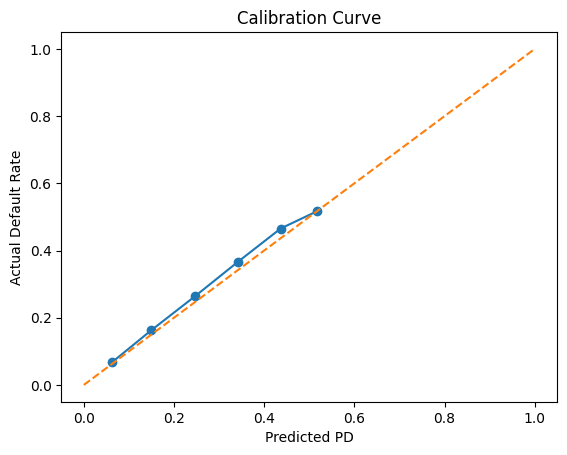

In [62]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_pred_woe, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted PD")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve")
plt.show()


In [63]:
test.groupby('risk_band')['default'].mean()


,default
risk_band,
Very High Risk,0.386388
High Risk,0.271434
Medium Risk,0.202562
Low Risk,0.138238
Very Low Risk,0.065471
